Для начала в начале ноутбука будем импортировать нужные нам библиотеки и настроим базовое логирование

In [38]:
import json
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Настройка логирования
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

В ячейке ниже загружаю данные из transactions_data.xlsx и clients_data.json

In [39]:
transactions = pd.read_excel('transactions_data.xlsx', engine='openpyxl')
logger.info(f'Транзакции загружены. Размер: {transactions.shape}')
transactions.head()

2026-03-02 20:57:17,081 - INFO - Транзакции загружены. Размер: (10000, 8)


,transaction_id,client_id,transaction_date,service,amount,payment_method,city,consultant
0,ff36597c-df41-44a0-9f46-6aa1fe615270,1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7,2025-01-04 00:02:20,Структурирование капитала,55838.059789,Банковский перевод,North Patrickport,Cheryl Waller
1,0d5263ec-413d-44d9-a9d3-a996e3a56b05,c940f45c-d29b-439a-8fa3-f75018cef528,2025-03-10 17:16:50,Структурирование капитала,37514.809209,Неизвестно,New Zacharyport,Frank Pollard
2,5e9a8978-df1c-483f-a53b-16149c93f11e,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,2025-02-13 19:43:49,Структурирование капитала,21022.146872,Неизвестно,Port Michellemouth,Alexandra Meyer
3,524031ea-56e2-410a-aee2-e8fc6ae3fbc5,NaN,2025-03-02 03:14:10,Финансовое планирование,2313.980219,Неизвестно,Erichaven,Patricia Haas
4,421aaf04-c97d-42ac-b35f-09a56bbaf910,3f43d7bc-37f0-4535-8391-51702d6ff81e,2025-03-18 21:00:36,Структурирование капитала,5636.586955,Неизвестно,Bondstad,Melissa Pena


In [40]:
# Загружаем клиентов в контекстном менеджере
with open('clients_data.json', 'r', encoding='utf-8') as f:
    clients_data = json.load(f)
clients = pd.DataFrame(clients_data)
logger.info(f"Клиенты загружены. Размер: {clients.shape}")
clients.head()

2026-03-02 20:57:17,153 - INFO - Клиенты загружены. Размер: (9799, 4)


,id,age,gender,net_worth
0,1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7,41.0,Мужчина,2514729.46
1,c940f45c-d29b-439a-8fa3-f75018cef528,28.0,Мужчина,566568.29
2,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,55.0,Женщина,1896001.28
3,NaN,38.0,Женщина,4538759.60
4,3f43d7bc-37f0-4535-8391-51702d6ff81e,31.0,Мужчина,4865849.92


Вывдем общую информацию о данных

In [41]:
print("=== Транзакции ===")
transactions.info()
print("\n=== Клиенты ===")
clients.info()

=== Транзакции ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    9526 non-null   str    
 1   client_id         9798 non-null   str    
 2   transaction_date  10000 non-null  object 
 3   service           10000 non-null  str    
 4   amount            9540 non-null   float64
 5   payment_method    10000 non-null  str    
 6   city              10000 non-null  str    
 7   consultant        10000 non-null  str    
dtypes: float64(1), object(1), str(6)
memory usage: 625.1+ KB

=== Клиенты ===
<class 'pandas.DataFrame'>
RangeIndex: 9799 entries, 0 to 9798
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         9798 non-null   str    
 1   age        8816 non-null   float64
 2   gender     6480 non-null   str    
 3   net_worth  9324 non-null   float64
d

Теперь займемся очисткой данных

In [42]:
# Удаляем пропуски и дубликаты в transaction_id
def clean_transaction_ids(df):
    initial_len = len(df)
    df = df.dropna(subset=['transaction_id'])
    df['transaction_id'] = df['transaction_id'].astype(str)
    df = df.drop_duplicates(subset=['transaction_id'])
    logger.info(f"Удалено {initial_len - len(df)} записей с проблемами transaction_id")
    return df


transactions = clean_transaction_ids(transactions)

2026-03-02 20:57:17,360 - INFO - Удалено 474 записей с проблемами transaction_id


In [43]:
# Удаление пропусков в client_id
def clean_client_ids(df):
    initial_len = len(df)
    df = df.dropna(subset=['client_id'])
    df['client_id'] = df['client_id'].astype(str)
    logger.info(f"Удалено {initial_len - len(df)} записей без client_id")
    return df


transactions = clean_client_ids(transactions)

2026-03-02 20:57:17,463 - INFO - Удалено 191 записей без client_id


In [44]:
# Заменяем пустые строки на NaN в категориальных полях
def replace_empty_strings(df, columns):
    for col in columns:
        if col in df.columns:
            df[col] = df[col].replace('', np.nan)
    logger.info(f"Пустые строки заменены на NaN в {columns}")
    return df


categorical_cols = ['service', 'payment_method', 'city', 'consultant']
transactions = replace_empty_strings(transactions, categorical_cols)

2026-03-02 20:57:17,521 - INFO - Пустые строки заменены на NaN в ['service', 'payment_method', 'city', 'consultant']


В ячейках не формализованы неизвестные данные, поэтому придется их привести к одному виду

In [45]:
def replace_unknown_markers(df, markers_dict):
    for col, markers in markers_dict.items():
        if col in df.columns:
            df[col] = df[col].replace(markers, np.nan)
    logger.info("Маркеры неизвестности заменены на NaN")
    return df


unknown_markers = {
    'service': ['Неизвестная услуга'],
    'payment_method': ['Неизвестно'],
    'city': ['Неизвестный город'],
    'consultant': ['Неизвестный консультант'],
    'transaction_date': ['INVALID_DATE']
}
transactions = replace_unknown_markers(transactions, unknown_markers)

2026-03-02 20:57:17,573 - INFO - Маркеры неизвестности заменены на NaN


In [46]:
# Читсим даты
def clean_dates(df):
    initial_len = len(df)
    df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
    df = df.dropna(subset=['transaction_date'])
    logger.info(f"Удалено {initial_len - len(df)} записей с некорректной датой")
    return df


transactions = clean_dates(transactions)

2026-03-02 20:57:17,626 - INFO - Удалено 941 записей с некорректной датой


In [47]:
# Очищаем суммы (Удалим пропуски и отрицательные значения)
def clean_amounts(df):
    initial_len = len(df)
    df = df.dropna(subset=['amount'])
    df = df[df['amount'] > 0]
    logger.info(f"Удалено {initial_len - len(df)} записей с пропущенной или отрицательной суммой")
    return df


transactions = clean_amounts(transactions)

2026-03-02 20:57:17,657 - INFO - Удалено 382 записей с пропущенной или отрицательной суммой


In [48]:
# Удаляем полные дубликаты
def remove_full_duplicates(df):
    initial_len = len(df)
    df = df.drop_duplicates()
    logger.info(f"Удалено {initial_len - len(df)} полностью дублирующихся строк")
    return df


transactions = remove_full_duplicates(transactions)

2026-03-02 20:57:17,701 - INFO - Удалено 0 полностью дублирующихся строк


Итоговый размер очищенных данных

In [49]:
logger.info(f"Размер очищенных транзакций: {transactions.shape}")
transactions.head()

2026-03-02 20:57:17,732 - INFO - Размер очищенных транзакций: (8012, 8)


,transaction_id,client_id,transaction_date,service,amount,payment_method,city,consultant
0,ff36597c-df41-44a0-9f46-6aa1fe615270,1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7,2025-01-04 00:02:20,Структурирование капитала,55838.059789,Банковский перевод,North Patrickport,Cheryl Waller
1,0d5263ec-413d-44d9-a9d3-a996e3a56b05,c940f45c-d29b-439a-8fa3-f75018cef528,2025-03-10 17:16:50,Структурирование капитала,37514.809209,NaN,New Zacharyport,Frank Pollard
2,5e9a8978-df1c-483f-a53b-16149c93f11e,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,2025-02-13 19:43:49,Структурирование капитала,21022.146872,NaN,Port Michellemouth,Alexandra Meyer
4,421aaf04-c97d-42ac-b35f-09a56bbaf910,3f43d7bc-37f0-4535-8391-51702d6ff81e,2025-03-18 21:00:36,Структурирование капитала,5636.586955,NaN,Bondstad,Melissa Pena
5,822d5795-4f08-4a7a-9692-7f5863945bdf,900f7d6b-ee7f-49e6-ae9f-e5ea9e04ab4c,2025-02-21 21:50:30,Инвестиционное консультирование,85575.773285,Кредитная карта,West Jaymouth,Harold Gibson


### Анализ транзакций

In [50]:
# Топ-5 наиболее популярных по кол-ву заказов
top_services = transactions['service'].value_counts().head(5)
logger.info("Топ-5 услуг по количеству заказов:")
logger.info(top_services)

2026-03-02 20:57:17,796 - INFO - Топ-5 услуг по количеству заказов:
2026-03-02 20:57:17,797 - INFO - service
Инвестиционное консультирование    1956
Управление активами                1606
Финансовое планирование            1242
Налоговое планирование             1218
Структурирование капитала          1196
Name: count, dtype: int64


In [51]:
# Средняя сумма транзакций по каждому городу
avg_amount_city = transactions.groupby('city')['amount'].mean().sort_values(ascending=False)
logger.info("Средняя сумма по городам (первые 5):")
logger.info(avg_amount_city.head())

2026-03-02 20:57:18,002 - INFO - Средняя сумма по городам (первые 5):
2026-03-02 20:57:18,003 - INFO - city
Michellehaven         58331.607880
East Rachelmouth      57472.974696
Port Michellemouth    57147.046358
New Tommyborough      54873.148506
North Lauriebury      54052.564197
Name: amount, dtype: float64


In [52]:
# Услуга с наибольшей выручкой
revenue_by_service = transactions.groupby('service')['amount'].sum().sort_values(ascending=False)
top_service = revenue_by_service.index[0]
top_revenue = revenue_by_service.iloc[0]
logger.info(f"Услуга с максимальной выручкой: {top_service} ({top_revenue:,.2f})")

2026-03-02 20:57:18,052 - INFO - Услуга с максимальной выручкой: Инвестиционное консультирование (98,211,881.93)


In [53]:
# Процент транзакций по способам оплаты
payment_pct = transactions['payment_method'].value_counts(normalize=True) * 100
logger.info("Процент транзакций по способам оплаты:")
logger.info(payment_pct)

2026-03-02 20:57:18,121 - INFO - Процент транзакций по способам оплаты:
2026-03-02 20:57:18,122 - INFO - payment_method
Кредитная карта       44.561745
Банковский перевод    38.491457
Наличные              11.084873
Криптовалюта           5.861925
Name: proportion, dtype: float64


In [54]:
# Выручка за послекдний месяц
max_date = transactions['transaction_date'].max()
first_day_last_month = max_date.replace(day=1)
last_month_revenue = transactions[transactions['transaction_date'] >= first_day_last_month]['amount'].sum()
logger.info(
    f"Выручка за последний месяц (с {first_day_last_month.date()} по {max_date.date()}): {last_month_revenue:,.2f}")

2026-03-02 20:57:18,162 - INFO - Выручка за последний месяц (с 2025-03-01 по 2025-03-20): 97,284,214.93


### Объединение данных с данными клиентов

In [55]:
# Для начала я для удобства переименую колонки id в client_id
clients = clients.rename(columns={'id': 'client_id'})
clients.head()

,client_id,age,gender,net_worth
0,1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7,41.0,Мужчина,2514729.46
1,c940f45c-d29b-439a-8fa3-f75018cef528,28.0,Мужчина,566568.29
2,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,55.0,Женщина,1896001.28
3,NaN,38.0,Женщина,4538759.60
4,3f43d7bc-37f0-4535-8391-51702d6ff81e,31.0,Мужчина,4865849.92


In [56]:
# Приводим id к строке
transactions['client_id'] = transactions['client_id'].astype(str)
clients['client_id'] = clients['client_id'].astype(str)

merged = pd.merge(transactions, clients, on='client_id', how='inner')
logger.info(f"Объединено {len(merged)} записей")
merged.head()

2026-03-02 20:57:18,258 - INFO - Объединено 8012 записей


,transaction_id,client_id,transaction_date,service,amount,payment_method,city,consultant,age,gender,net_worth
0,ff36597c-df41-44a0-9f46-6aa1fe615270,1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7,2025-01-04 00:02:20,Структурирование капитала,55838.059789,Банковский перевод,North Patrickport,Cheryl Waller,41.0,Мужчина,2514729.46
1,0d5263ec-413d-44d9-a9d3-a996e3a56b05,c940f45c-d29b-439a-8fa3-f75018cef528,2025-03-10 17:16:50,Структурирование капитала,37514.809209,NaN,New Zacharyport,Frank Pollard,28.0,Мужчина,566568.29
2,5e9a8978-df1c-483f-a53b-16149c93f11e,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,2025-02-13 19:43:49,Структурирование капитала,21022.146872,NaN,Port Michellemouth,Alexandra Meyer,55.0,Женщина,1896001.28
3,421aaf04-c97d-42ac-b35f-09a56bbaf910,3f43d7bc-37f0-4535-8391-51702d6ff81e,2025-03-18 21:00:36,Структурирование капитала,5636.586955,NaN,Bondstad,Melissa Pena,31.0,Мужчина,4865849.92
4,822d5795-4f08-4a7a-9692-7f5863945bdf,900f7d6b-ee7f-49e6-ae9f-e5ea9e04ab4c,2025-02-21 21:50:30,Инвестиционное консультирование,85575.773285,Кредитная карта,West Jaymouth,Harold Gibson,59.0,Женщина,3992281.84


In [57]:
# Добавим клолонку с уровнем капитала
def wealth_level(row):
    if row['net_worth'] < 100_000:
        return 'Низкий капитал'
    elif row['net_worth'] <= 1_000_000:
        return 'Средний капитал'
    else:
        return 'Высокий капитал'


merged['wealth_level'] = merged.apply(wealth_level, axis=1)
merged[['client_id', 'net_worth', 'wealth_level']].head()

,client_id,net_worth,wealth_level
0,1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7,2514729.46,Высокий капитал
1,c940f45c-d29b-439a-8fa3-f75018cef528,566568.29,Средний капитал
2,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,1896001.28,Высокий капитал
3,3f43d7bc-37f0-4535-8391-51702d6ff81e,4865849.92,Высокий капитал
4,900f7d6b-ee7f-49e6-ae9f-e5ea9e04ab4c,3992281.84,Высокий капитал


In [58]:
# Выручка по категориямс клиентов
revenue_by_wealth = merged.groupby('wealth_level')['amount'].sum().sort_values(ascending=False)
logger.info("Выручка по категориям клиентов:")
logger.info(revenue_by_wealth)

2026-03-02 20:57:18,529 - INFO - Выручка по категориям клиентов:
2026-03-02 20:57:18,530 - INFO - wealth_level
Высокий капитал    3.263504e+08
Средний капитал    6.539217e+07
Низкий капитал     6.813887e+06
Name: amount, dtype: float64


## Визуализация данных

Распределение сумм транзакций

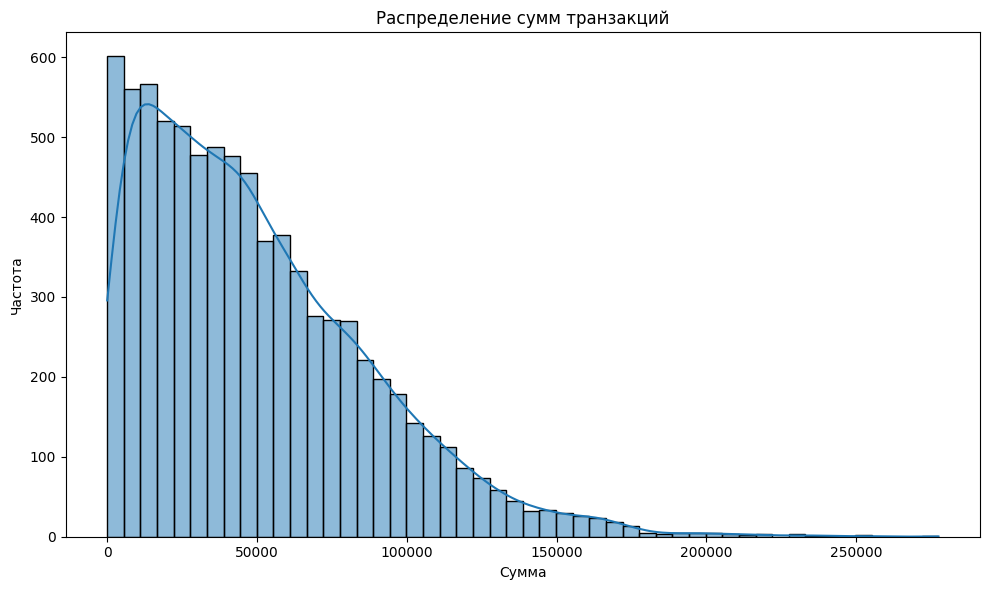

In [59]:
plt.figure(figsize=(10, 6))
sns.histplot(transactions['amount'], bins=50, kde=True)
plt.title('Распределение сумм транзакций')
plt.xlabel('Сумма')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

Диаграмма выручки по услугам (топ-10)

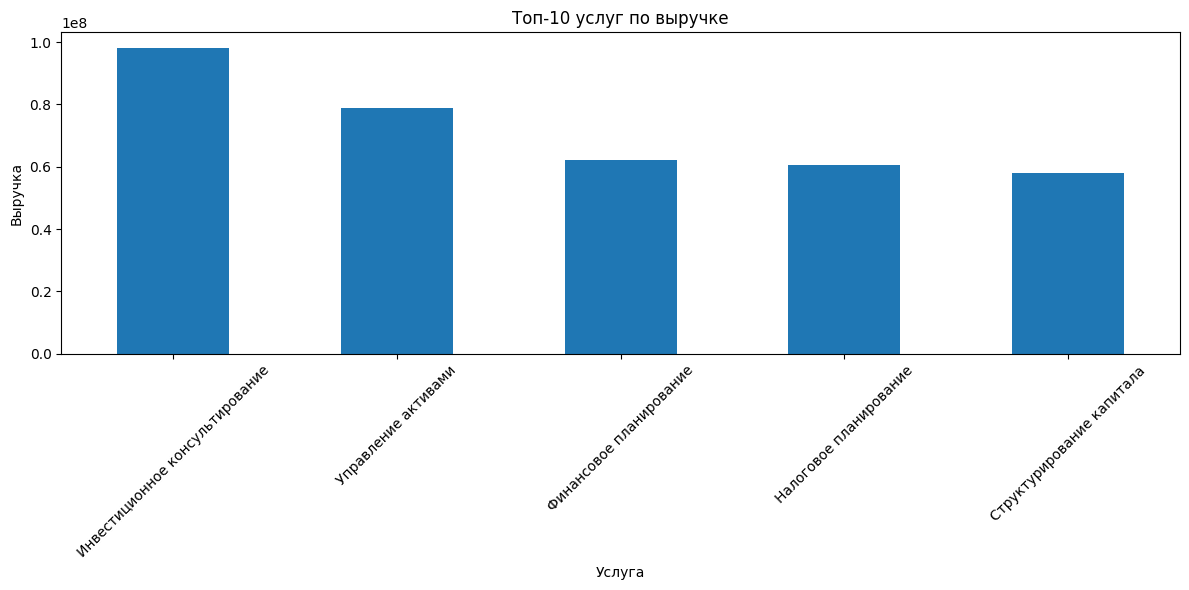

In [60]:
top10_revenue = revenue_by_service.head(10)
plt.figure(figsize=(12, 6))
top10_revenue.plot(kind='bar')
plt.title('Топ-10 услуг по выручке')
plt.xlabel('Услуга')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Зависимость средней суммы транзакции от возраста клиента

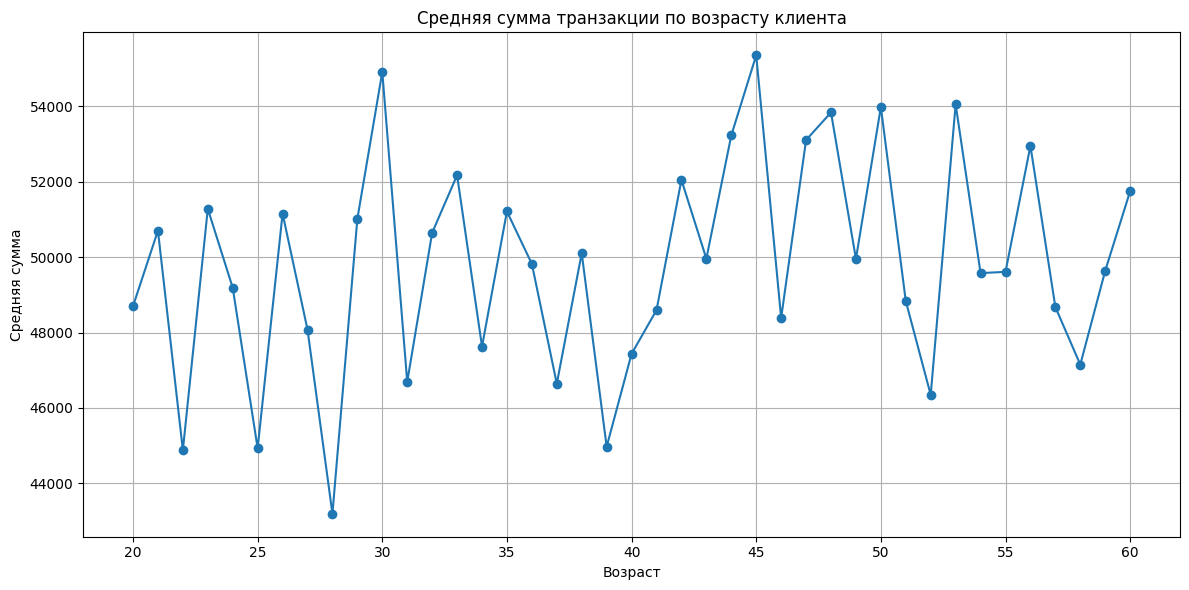

In [61]:
avg_by_age = merged.groupby('age')['amount'].mean().dropna()
plt.figure(figsize=(12, 6))
avg_by_age.plot(marker='o', linestyle='-')
plt.title('Средняя сумма транзакции по возрасту клиента')
plt.xlabel('Возраст')
plt.ylabel('Средняя сумма')
plt.grid(True)
plt.tight_layout()
plt.show()

### Прогнозирование спроса на следующий месяц

In [62]:
# Агрегация по месяцам
transactions['year_month'] = transactions['transaction_date'].dt.to_period('M')
monthly_counts = transactions.groupby('year_month').size().reset_index(name='count')
monthly_counts['month_num'] = range(len(monthly_counts))
monthly_counts.head()

,year_month,count,month_num
0,2025-01,3143,0
1,2025-02,2894,1
2,2025-03,1975,2


Используем линейную регрессию для прогноза. Почему именно регрессию используем, потому что прогнозирование числового значения на основе временного ряда относится к задачам регрессии.

Модель дает уравнение тренда: count = a * month + b. Коэф a показывает среднемесяный прирост/убыль, что легко объяснить бизнес-пользователям.

In [63]:
X = monthly_counts[['month_num']].values
y = monthly_counts['count'].values

model = LinearRegression()
model.fit(X, y)

# Прогноз на следующий месяц
next_month_num = len(monthly_counts)
pred = model.predict([[next_month_num]])[0]
last_month = monthly_counts['year_month'].iloc[-1]
next_month = last_month + 1
logger.info(f"Прогноз количества транзакций на {next_month}: {pred:.0f}")

2026-03-02 20:57:19,202 - INFO - Прогноз количества транзакций на 2025-04: 1503


2026-03-02 20:59:51,435 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-02 20:59:51,437 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


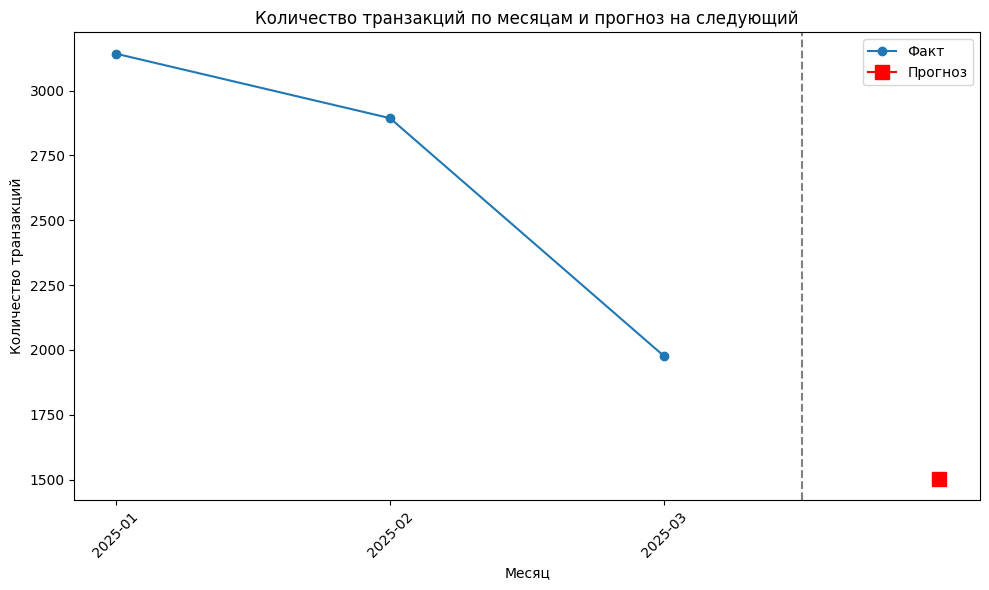

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_counts['year_month'].astype(str), monthly_counts['count'], marker='o', label='Факт')
plt.axvline(x=len(monthly_counts) - 0.5, color='gray', linestyle='--')
plt.plot([len(monthly_counts)], [pred], marker='s', color='red', markersize=10, label='Прогноз')
plt.title('Количество транзакций по месяцам и прогноз на следующий')
plt.xlabel('Месяц')
plt.ylabel('Количество транзакций')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()